In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import ast
import os

df = pd.read_csv("results/fh_rflp_candidates.csv")
print(f"Loaded {len(df)} candidates")

# Enzyme cost estimates (USD per 100 reactions, from NEB catalog)
# Common enzymes are cheaper — this rewards practical choices
enzyme_costs = {
    "EcoRV":     15,
    "EcoT38I":   20,
    "MaeI":      25,
    "BsrDI":     30,
    "PaeI":      30,
    "BtrI":      35,
    "BstDSI":    35,
    "AccBSI":    35,
    "Eam1104I":  40,
    "BtgZI":     40,
    "GsaI":      40,
    "PfoI":      40,
    "GsuI":      45,
    "Hpy99I":    45,
    "BshVI":     45,
    "BsaJI":     45,
    "BtsIMutI":  50,
    "Hpy188III": 50,
    "LmnI":      55,
    "BstSFI":    55,
    "MspJI":     55,
    "MnlI":      55,
    "AsuHPI":    60,
}

df["enzyme_cost"] = df["best_enzyme"].map(enzyme_costs).fillna(50)

print("Enzyme costs assigned")
print(df[["gene","cdna_change","best_enzyme","enzyme_cost"]].head(8))

Loaded 23 candidates
Enzyme costs assigned
   gene cdna_change best_enzyme  enzyme_cost
0  LDLR    c.408C>G     EcoT38I           20
1  LDLR    c.155G>T        PfoI           40
2  LDLR    c.457T>C        GsuI           45
3  LDLR   c.1840T>G      Hpy99I           45
4  LDLR   c.1054T>G    Eam1104I           40
5  LDLR   c.1961T>G    Eam1104I           40
6  LDLR   c.1865A>T       EcoRV           15
7  LDLR    c.986G>C       BsrDI           30


In [2]:
def compute_rflp_score(row):
    """
    Score each variant 0-10 for RFLP panel suitability.
    
    Components:
      - Fragment difference (3 pts) : bigger diff = clearer gel band
      - Gel quality         (3 pts) : excellent > good > poor
      - Enzyme cost         (2 pts) : cheaper = better
      - Gene diversity      (2 pts) : reward APOB and PCSK9
                                      since LDLR dominates
    """
    score = 0.0
    
    # 1. Fragment difference — max 3 pts
    # 300bp diff = full 3pts, scales linearly down
    diff = row["frag_diff_bp"]
    score += min(diff / 300, 1.0) * 3
    
    # 2. Gel quality — max 3 pts
    quality_scores = {
        "excellent": 3.0,
        "good":      2.0,
        "poor":      0.5,
        "unusable":  0.0
    }
    score += quality_scores.get(row["gel_quality"], 0)
    
    # 3. Enzyme cost — max 2 pts
    # $15 = full 2pts, $60 = 0pts, linear scale
    cost = row["enzyme_cost"]
    score += max(0, (60 - cost) / 45) * 2
    
    # 4. Gene diversity bonus — max 2 pts
    # LDLR is over-represented so we boost other genes
    gene_bonus = {"LDLR": 0.5, "APOB": 2.0, "PCSK9": 2.0}
    score += gene_bonus.get(row["gene"], 0.5)
    
    return round(score, 2)


# Apply scoring
df["rflp_score"] = df.apply(compute_rflp_score, axis=1)

# Sort by score
df_scored = df.sort_values("rflp_score", ascending=False).reset_index(drop=True)

print("Scores assigned — top 15:")
print(df_scored[[
    "gene","cdna_change","best_enzyme",
    "frag_diff_bp","gel_quality",
    "enzyme_cost","rflp_score"
]].head(15).to_string())

Scores assigned — top 15:
    gene                  cdna_change best_enzyme  frag_diff_bp gel_quality  enzyme_cost  rflp_score
0   APOB                    c.9721G>T     EcoT38I           300   excellent           20        9.78
1   APOB                   c.11470C>T        MaeI           300   excellent           25        9.56
2   LDLR                    c.1865A>T       EcoRV           298   excellent           15        8.48
3   LDLR                     c.408C>G     EcoT38I           295   excellent           20        8.23
4   APOB                    c.8602G>T      BstSFI           300   excellent           55        8.22
5   APOB                    c.5303C>A    Eam1104I           228   excellent           40        8.17
6   LDLR                     c.483C>G        PaeI           299   excellent           30        7.82
7   LDLR                     c.986G>C       BsrDI           292   excellent           30        7.75
8   LDLR                     c.325T>A        BtrI           300  

In [3]:
def select_panel(df_scored, n=10):
    """
    Select top 10 mutations ensuring:
    - No more than 6 from any single gene
    - No enzyme used more than twice
    - All gel quality excellent or good
    """
    selected = []
    gene_counts   = {"LDLR": 0, "APOB": 0, "PCSK9": 0}
    enzyme_counts = {}
    
    for _, row in df_scored.iterrows():
        if len(selected) >= n:
            break
        
        gene   = row["gene"]
        enzyme = row["best_enzyme"]
        
        # Max 6 from any one gene
        if gene_counts.get(gene, 0) >= 6:
            continue
        
        # Max 2 uses of any one enzyme
        if enzyme_counts.get(enzyme, 0) >= 2:
            continue
        
        selected.append(row)
        gene_counts[gene] = gene_counts.get(gene, 0) + 1
        enzyme_counts[enzyme] = enzyme_counts.get(enzyme, 0) + 1
    
    return pd.DataFrame(selected).reset_index(drop=True)


panel = select_panel(df_scored, n=10)

print("=" * 65)
print("  FINAL RECOMMENDED FH RFLP SCREENING PANEL")
print("=" * 65)
print(panel[[
    "gene","cdna_change","protein_change",
    "best_enzyme","change_type",
    "frag_diff_bp","enzyme_cost","rflp_score"
]].to_string())
print()
print(f"Total mutations in panel: {len(panel)}")
print(f"Gene breakdown:")
print(panel["gene"].value_counts().to_string())
print(f"\nEstimated cost per sample: ${panel['enzyme_cost'].mean():.0f} avg per enzyme")
print(f"Score range: {panel['rflp_score'].min()} – {panel['rflp_score'].max()}")

  FINAL RECOMMENDED FH RFLP SCREENING PANEL
   gene                  cdna_change              protein_change best_enzyme     change_type  frag_diff_bp  enzyme_cost  rflp_score
0  APOB                    c.9721G>T                      E3241*     EcoT38I  site_destroyed           300           20        9.78
1  APOB                   c.11470C>T                      Q3824*        MaeI    site_created           300           25        9.56
2  LDLR                    c.1865A>T  D454V, D495V, D581V, D622V       EcoRV  site_destroyed           298           15        8.48
3  LDLR                     c.408C>G                 D136E, D95E     EcoT38I    site_created           295           20        8.23
4  APOB                    c.8602G>T                      E2868*      BstSFI    site_created           300           55        8.22
5  APOB                    c.5303C>A                      S1768*    Eam1104I  site_destroyed           228           40        8.17
6  LDLR                     c.48

In [4]:
# Save final panel
panel.to_csv("results/final_panel.csv", index=False)

# Build a clean publication table
pub_table = panel[[
    "gene", "cdna_change", "protein_change",
    "best_enzyme", "change_type",
    "wt_frags", "mut_frags",
    "frag_diff_bp", "enzyme_cost",
    "gel_quality", "rflp_score"
]].copy()

# Clean up column names for publication
pub_table.columns = [
    "Gene", "cDNA Change", "Protein Change",
    "Enzyme", "Site Change",
    "WT Fragments (bp)", "Mutant Fragments (bp)",
    "Fragment Diff (bp)", "Enzyme Cost (USD)",
    "Gel Quality", "RFLP Score"
]

# Clean up the site change labels
pub_table["Site Change"] = pub_table["Site Change"].str.replace(
    "_", " ").str.title()

print("Publication table:")
print(pub_table.to_string())
print()

# Save as CSV for paper
pub_table.to_csv("results/publication_table.csv", index=False)
print("Saved: results/publication_table.csv")

Publication table:
   Gene                  cDNA Change              Protein Change    Enzyme     Site Change WT Fragments (bp) Mutant Fragments (bp)  Fragment Diff (bp)  Enzyme Cost (USD) Gel Quality  RFLP Score
0  APOB                    c.9721G>T                      E3241*   EcoT38I  Site Destroyed        [301, 300]                 [601]                 300                 20   excellent        9.78
1  APOB                   c.11470C>T                      Q3824*      MaeI    Site Created             [601]            [300, 301]                 300                 25   excellent        9.56
2  LDLR                    c.1865A>T  D454V, D495V, D581V, D622V     EcoRV  Site Destroyed        [303, 298]                 [601]                 298                 15   excellent        8.48
3  LDLR                     c.408C>G                 D136E, D95E   EcoT38I    Site Created             [601]            [306, 295]                 295                 20   excellent        8.23
4  APOB    

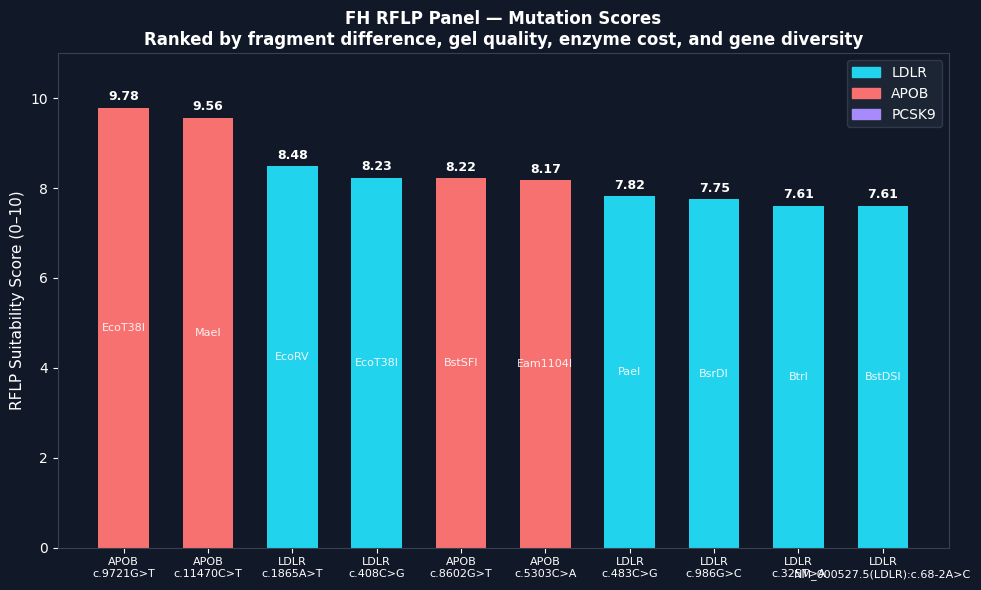

Saved: results/figures/panel_scores.png


In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("#111827")
ax.set_facecolor("#111827")

# Color bars by gene
colors = {"LDLR": "#22d3ee", "APOB": "#f87171", "PCSK9": "#a78bfa"}
bar_colors = [colors[g] for g in panel["gene"]]

# Short labels for x axis
labels = [f"{row['gene']}\n{row['cdna_change']}" 
          for _, row in panel.iterrows()]

bars = ax.bar(range(len(panel)), panel["rflp_score"],
              color=bar_colors, edgecolor="none", width=0.6)

# Score labels on top of bars
for i, (bar, score) in enumerate(zip(bars, panel["rflp_score"])):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f"{score}",
            ha="center", va="bottom",
            color="white", fontsize=9, fontweight="bold")

# Enzyme labels inside bars
for i, (bar, row) in enumerate(zip(bars, panel.itertuples())):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height()/2,
            row.best_enzyme,
            ha="center", va="center",
            color="white", fontsize=8, alpha=0.9)

# Legend
legend_patches = [
    mpatches.Patch(color="#22d3ee", label="LDLR"),
    mpatches.Patch(color="#f87171", label="APOB"),
    mpatches.Patch(color="#a78bfa", label="PCSK9"),
]
ax.legend(handles=legend_patches, loc="upper right",
          facecolor="#1f2937", edgecolor="#374151",
          labelcolor="white", fontsize=10)

ax.set_xticks(range(len(panel)))
ax.set_xticklabels(labels, color="white", fontsize=8)
ax.set_ylabel("RFLP Suitability Score (0–10)",
              color="white", fontsize=11)
ax.set_title("FH RFLP Panel — Mutation Scores\n"
             "Ranked by fragment difference, gel quality, enzyme cost, and gene diversity",
             color="white", fontsize=12, fontweight="bold")
ax.set_ylim(0, 11)
ax.tick_params(colors="white")
for spine in ax.spines.values():
    spine.set_edgecolor("#374151")
ax.yaxis.label.set_color("white")

plt.tight_layout()
plt.savefig("results/figures/panel_scores.png",
            dpi=200, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Saved: results/figures/panel_scores.png")

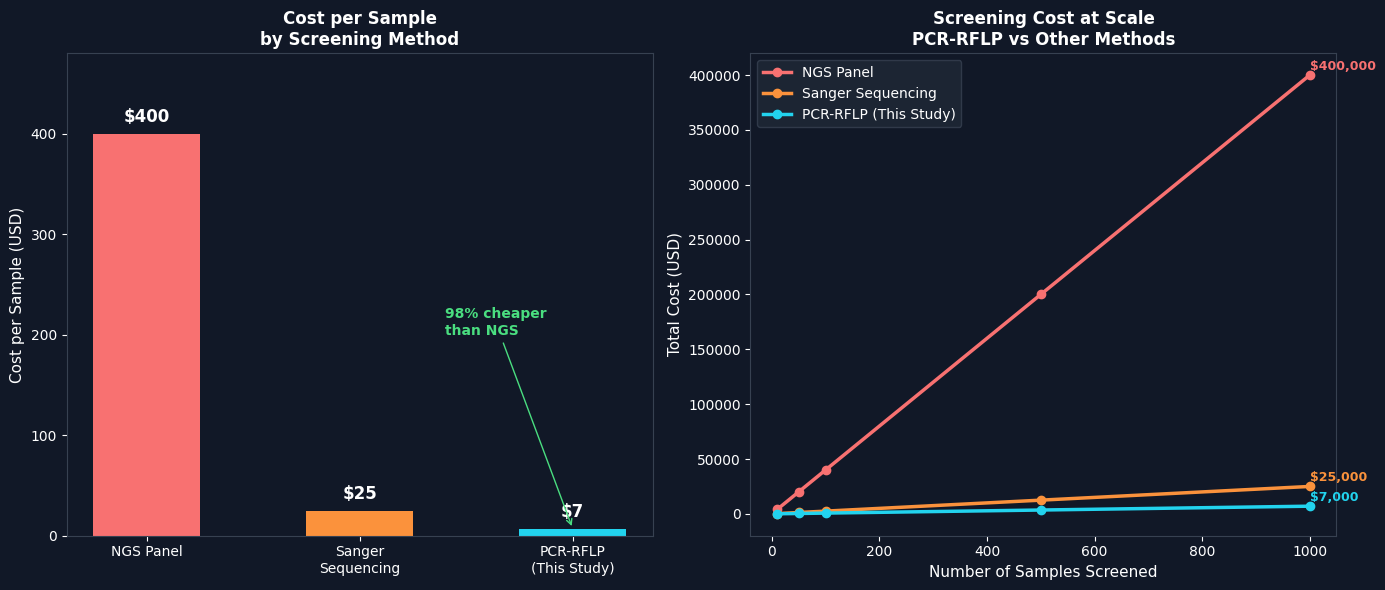

Saved: results/figures/cost_comparison.png

Phase 6 complete!


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor("#111827")

# ── Left chart: cost per sample comparison ──────────────────
ax1 = axes[0]
ax1.set_facecolor("#111827")

methods = ["NGS Panel", "Sanger\nSequencing", "PCR-RFLP\n(This Study)"]
costs   = [400, 25, 7]
colors  = ["#f87171", "#fb923c", "#22d3ee"]

bars = ax1.bar(methods, costs, color=colors, 
               edgecolor="none", width=0.5)

# Cost labels on bars
for bar, cost in zip(bars, costs):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 8,
             f"${cost}",
             ha="center", va="bottom",
             color="white", fontsize=12, fontweight="bold")

ax1.set_ylabel("Cost per Sample (USD)",
               color="white", fontsize=11)
ax1.set_title("Cost per Sample\nby Screening Method",
              color="white", fontsize=12, fontweight="bold")
ax1.set_ylim(0, 480)
ax1.tick_params(colors="white")
ax1.set_facecolor("#111827")
for spine in ax1.spines.values():
    spine.set_edgecolor("#374151")

# Savings annotation
ax1.annotate("98% cheaper\nthan NGS",
             xy=(2, 7), xytext=(1.4, 200),
             color="#4ade80", fontsize=10, fontweight="bold",
             arrowprops=dict(arrowstyle="->", color="#4ade80"))

# ── Right chart: cost at scale ───────────────────────────────
ax2 = axes[1]
ax2.set_facecolor("#111827")

sample_sizes = [10, 50, 100, 500, 1000]
ngs_costs    = [s * 400 for s in sample_sizes]
sanger_costs = [s * 25  for s in sample_sizes]
rflp_costs   = [s * 7   for s in sample_sizes]

ax2.plot(sample_sizes, ngs_costs,
         color="#f87171", linewidth=2.5,
         marker="o", markersize=6, label="NGS Panel")
ax2.plot(sample_sizes, sanger_costs,
         color="#fb923c", linewidth=2.5,
         marker="o", markersize=6, label="Sanger Sequencing")
ax2.plot(sample_sizes, rflp_costs,
         color="#22d3ee", linewidth=2.5,
         marker="o", markersize=6, label="PCR-RFLP (This Study)")

# End point labels
ax2.text(1000, ngs_costs[-1]    + 5000, "$400,000",
         color="#f87171", fontsize=9, fontweight="bold")
ax2.text(1000, sanger_costs[-1] + 5000, "$25,000",
         color="#fb923c", fontsize=9, fontweight="bold")
ax2.text(1000, rflp_costs[-1]   + 5000, "$7,000",
         color="#22d3ee", fontsize=9, fontweight="bold")

ax2.set_xlabel("Number of Samples Screened",
               color="white", fontsize=11)
ax2.set_ylabel("Total Cost (USD)",
               color="white", fontsize=11)
ax2.set_title("Screening Cost at Scale\nPCR-RFLP vs Other Methods",
              color="white", fontsize=12, fontweight="bold")
ax2.legend(facecolor="#1f2937", edgecolor="#374151",
           labelcolor="white", fontsize=10)
ax2.tick_params(colors="white")
for spine in ax2.spines.values():
    spine.set_edgecolor("#374151")

plt.tight_layout()
plt.savefig("results/figures/cost_comparison.png",
            dpi=200, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Saved: results/figures/cost_comparison.png")
print()
print("Phase 6 complete!")